# Paper: Enhancing Liver Cirrhosis Diagnosis Using Machine Learning With Explainable AI and Cross-Validated Hyperparameter Tuning Techniques
### Dataset used: Kaggle Cirrhosis Prediction Dataset
https://www.kaggle.com/code/josefroslan/cirrhosis-prediction/notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy import stats
#import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import chi2_contingency
from statsmodels.graphics.mosaicplot import mosaic
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_csv("D:/IDEAS Project/data/Indian Liver Patient Dataset (ILPD).csv",header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


# Data Cleaning and Preprocessing

In [3]:
df.columns = [
    "Age",
    "Gender",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Proteins",
    "Albumin",
    "Albumin_Globulin_Ratio",
    "Target"
]

In [4]:
df.columns

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin',
       'Albumin_Globulin_Ratio', 'Target'],
      dtype='str')

In [5]:
df.describe()

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_Globulin_Ratio,Target
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    str    
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Proteins              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_Globulin_Ratio      579 non-null    float64
 10  Target                      583 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 52.8 KB


In [7]:
# Drop missing values from affected columns
df = df.dropna(subset="Albumin_Globulin_Ratio")

df.info()

<class 'pandas.DataFrame'>
Index: 579 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         579 non-null    int64  
 1   Gender                      579 non-null    str    
 2   Total_Bilirubin             579 non-null    float64
 3   Direct_Bilirubin            579 non-null    float64
 4   Alkaline_Phosphotase        579 non-null    int64  
 5   Alamine_Aminotransferase    579 non-null    int64  
 6   Aspartate_Aminotransferase  579 non-null    int64  
 7   Total_Proteins              579 non-null    float64
 8   Albumin                     579 non-null    float64
 9   Albumin_Globulin_Ratio      579 non-null    float64
 10  Target                      579 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 56.9 KB


In [8]:
# Check for duplicated rows
duplicated_rows = df[df.duplicated()]
# Group by the duplicated rows and calculate their sum
sum_of_duplicated_rows = duplicated_rows.groupby(duplicated_rows.columns.tolist()).size().reset_index(name='count')
# Display the sum of duplicated rows
print(sum_of_duplicated_rows)

    Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0    18    Male              0.8               0.2                   282   
1    30    Male              1.6               0.4                   332   
2    31    Male              0.6               0.1                   175   
3    34    Male              4.1               2.0                   289   
4    36    Male              0.8               0.2                   158   
5    36    Male              5.3               2.3                   145   
6    38  Female              2.6               1.2                   410   
7    39    Male              1.9               0.9                   180   
8    40  Female              0.9               0.3                   293   
9    42    Male              8.9               4.5                   272   
10   49    Male              0.6               0.1                   218   
11   58    Male              1.0               0.5                   158   
12   72    M

In [9]:
df.describe()

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_Globulin_Ratio,Target
count,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000
mean,44.782383,3.315371,1.494128,291.366149,81.126079,110.414508,6.481693,3.138515,0.947064,1.284974
std,16.221786,6.227716,2.816499,243.561863,183.182845,289.850034,1.084641,0.794435,0.319592,0.451792
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,61.000000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


# Feature Transformation  
Transformation of continuous variables into categorical variables:

- `Age` : { `< 35` : Young Adult, `35 ≤ Middle-Aged Adult < 65`, `≥ 65` : Elderly }

- `Total_Bilirubin` : { `< 1.2` : normal, `≥ 1.2` : high }

- `Direct_Bilirubin` : { `< 0.3` : normal, `≥ 0.3` : high }

- `Total_Proteins` : { `< 6.0` : low, `6.0 ≤ normal < 8.3`, `≥ 8.3` : high }

- `Albumin` : { `< 3.4` : low, `3.4 ≤ normal < 5.4`, `≥ 5.4` : high }

- `Albumin_Globulin_Ratio` : { `< 1.0` : low, `1.0 ≤ normal < 2.5`, `≥ 2.5` : high }

- `Alkaline_Phosphotase (ALP)` : { `< 44` : low, `44 ≤ normal < 147`, `≥ 147` : high }

- `Aspartate_Aminotransferase (AST)` : { `< 8` : low, `8 ≤ normal < 40`, `≥ 40` : high }

- `Alamine_Aminotransferase (ALT)` : {  
  `≤ 40` : normal,  
  `41 – 120` : mildly elevated,  
  `121 – 400` : moderately elevated,  
  `> 400` : severely elevated  
}

In [10]:
# Age
bins = [0, 35, 65, float('inf')]  
labels = ['Young Adult', 'Middle-Aged Adult', 'Elderly']
df['Age'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Total Bilirubin
bins = [0, 1.2, float('inf')]  
labels = ['normal', 'high']
df['Total_Bilirubin'] = pd.cut(df['Total_Bilirubin'], bins=bins, labels=labels, right=False)

# Direct Bilirubin
bins = [0, 0.3, float('inf')]  
labels = ['normal', 'high']
df['Direct_Bilirubin'] = pd.cut(df['Direct_Bilirubin'], bins=bins, labels=labels, right=False)

# Albumin
bins = [0, 3.4, 5.4, float('inf')]
labels = ['low', 'normal', 'high' ]
df['Albumin'] = pd.cut(df['Albumin'], bins=bins, labels=labels, right=False)

# ALP
bins = [0, 44, 147, float('inf')]
labels = ['low', 'normal', 'high' ]
df['Alkaline_Phosphotase'] = pd.cut(df['Alkaline_Phosphotase'], bins=bins, labels=labels, right=False)

# AST
bins = [0, 8, 40, float('inf')]
labels = ['low', 'normal', 'high' ]
df['Aspartate_Aminotransferase'] = pd.cut(df['Aspartate_Aminotransferase'], bins=bins, labels=labels, right=False)

#Total Proteins
bins = [0, 6.0, 8.3, float('inf')]
labels = ['low', 'normal', 'high']
df['Total_Proteins'] = pd.cut(df['Total_Proteins'], bins=bins, labels=labels, right=False)

#Alamine Aminotransferase
bins = [0, 40, 120, 400, float('inf')]
labels = ['normal', 'mild', 'moderate', 'severe']
df['Alamine_Aminotransferase'] = pd.cut(df['Alamine_Aminotransferase'], bins=bins, labels=labels, right=False)

#A/G Ratio
bins = [0, 1.0, 2.5, float('inf')]
labels = ['low', 'normal', 'high']
df['Albumin_Globulin_Ratio'] = pd.cut(df['Albumin_Globulin_Ratio'], bins=bins, labels=labels, right=False)

# Display the DataFrame with the new categorical column
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_Globulin_Ratio,Target
0,Elderly,Female,normal,normal,high,normal,normal,normal,low,low,1
1,Middle-Aged Adult,Male,high,high,high,mild,high,normal,low,low,1
2,Middle-Aged Adult,Male,high,high,high,mild,high,normal,low,low,1
3,Middle-Aged Adult,Male,normal,high,high,normal,normal,normal,normal,normal,1
4,Elderly,Male,high,high,high,normal,high,normal,low,low,1


# Exploratory Data Analysis 

### Target

In [ ]:
# Create a count plot
sns.countplot(data=df, x='Target', palette='Set2')
plt.title('Distribution of Target')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

pliv_cirr = len(df[df.Target == '1'])
pliv_cirr_rate = round((plive_cirr / len(df))*100, 2)
print("Positive Liver Cirrhosis Rate: "+ str(pliv_cirr_rate) + "%.")

### Age

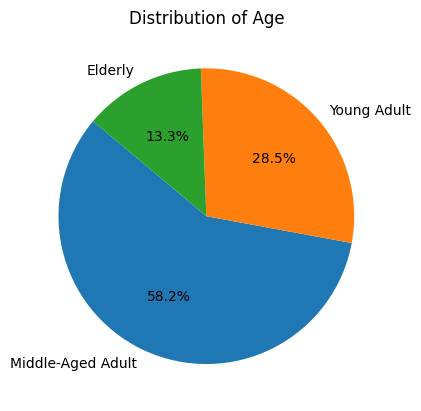

In [11]:
age_counts = df['Age'].value_counts()
# Create a pie chart
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Age')
plt.show()

Most patients are middle-aged adults.

### Gender

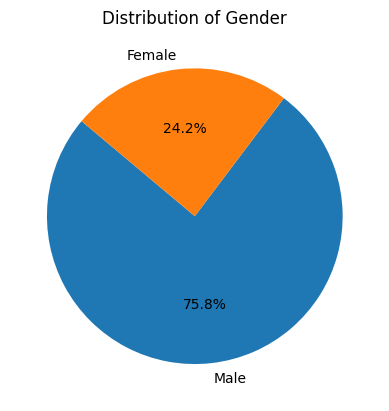

In [12]:
gen_counts = df['Gender'].value_counts()

# Create a pie chart
plt.pie(gen_counts, labels=gen_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Gender')
plt.show()

- Most of the patients are males.
- The distribution of genders is unbalanced.

## Hypothesis Testing

### Age vs Target

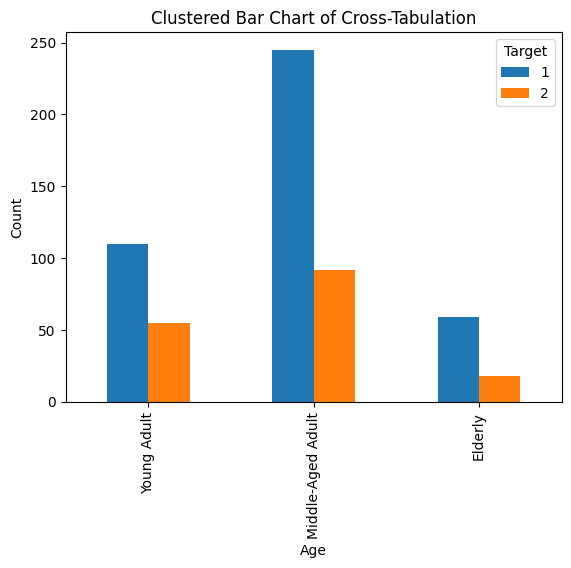

Cross-Tabulation:
Target               1   2
Age                       
Young Adult        110  55
Middle-Aged Adult  245  92
Elderly             59  18
P-value: 0.20993820440259006


In [13]:
# Create a cross-tabulation (contingency table)
Xtab = pd.crosstab(df['Age'], df['Target'])

# Plot a clustered bar chart
Xtab.plot(kind='bar')
plt.title("Clustered Bar Chart of Cross-Tabulation")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend(title="Target")
plt.show()

# Perform the chi-square test
chi2, pval, dof, expected = chi2_contingency(Xtab)

# Output the results
print("Cross-Tabulation:")
print(Xtab)
print("P-value:", pval)

Middle-aged adults show the highest number of liver cirrhosis cases.

### Total Bilirubin vs Target

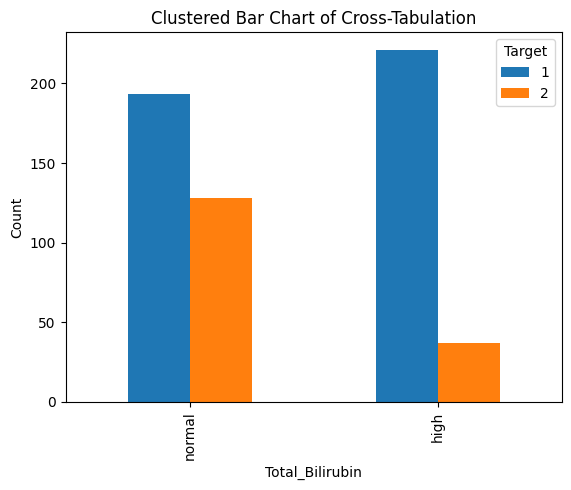

Cross-Tabulation:
Target             1    2
Total_Bilirubin          
normal           193  128
high             221   37
P-value: 2.5125986942148382e-11


In [14]:
# Create a cross-tabulation (contingency table)
Xtab = pd.crosstab(df['Total_Bilirubin'], df['Target'])

# Plot a clustered bar chart
Xtab.plot(kind='bar')
plt.title("Clustered Bar Chart of Cross-Tabulation")
plt.xlabel("Total_Bilirubin")
plt.ylabel("Count")
plt.legend(title="Target")
plt.show()

# Perform the chi-square test
chi2, pval, dof, expected = chi2_contingency(Xtab)

# Output the results
print("Cross-Tabulation:")
print(Xtab)
print("P-value:", pval)

Higher total bilirubin levels are strongly associated with liver disease.

### Direct Bilirubin vs Target

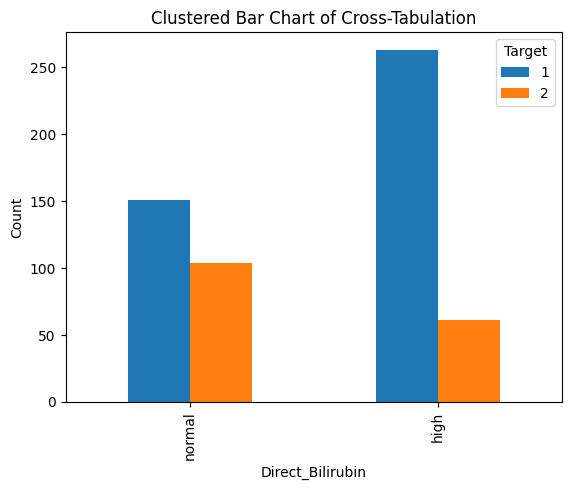

Cross-Tabulation:
Target              1    2
Direct_Bilirubin          
normal            151  104
high              263   61
P-value: 1.0790955785000285e-08


In [15]:
# Create a cross-tabulation (contingency table)
Xtab = pd.crosstab(df['Direct_Bilirubin'], df['Target'])

# Plot a clustered bar chart
Xtab.plot(kind='bar')
plt.title("Clustered Bar Chart of Cross-Tabulation")
plt.xlabel("Direct_Bilirubin")
plt.ylabel("Count")
plt.legend(title="Target")
plt.show()

# Perform the chi-square test
chi2, pval, dof, expected = chi2_contingency(Xtab)

# Output the results
print("Cross-Tabulation:")
print(Xtab)
print("P-value:", pval)

Higher direct bilirubin levels are strongly associated with liver disease.

### Albumin vs Target

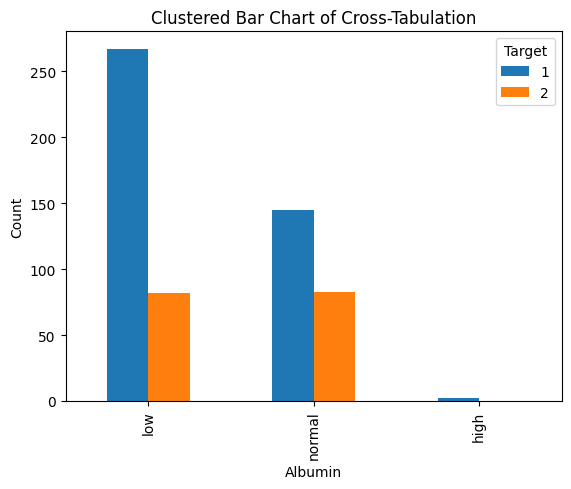

Cross-Tabulation:
Target     1   2
Albumin         
low      267  82
normal   145  83
high       2   0
P-value: 0.002386267245125296


In [16]:
Xtab = pd.crosstab(df['Albumin'], df['Target'])

# Plot a clustered bar chart
Xtab.plot(kind='bar')
plt.title("Clustered Bar Chart of Cross-Tabulation")
plt.xlabel("Albumin")
plt.ylabel("Count")
plt.legend(title="Target")
plt.show()

# Perform the chi-square test
chi2, pval, dof, expected = chi2_contingency(Xtab)

# Output the results
print("Cross-Tabulation:")
print(Xtab)
print("P-value:", pval)

Lower albumin levels are associated with liver disease.

### Alkaline_Phosphotase vs Target

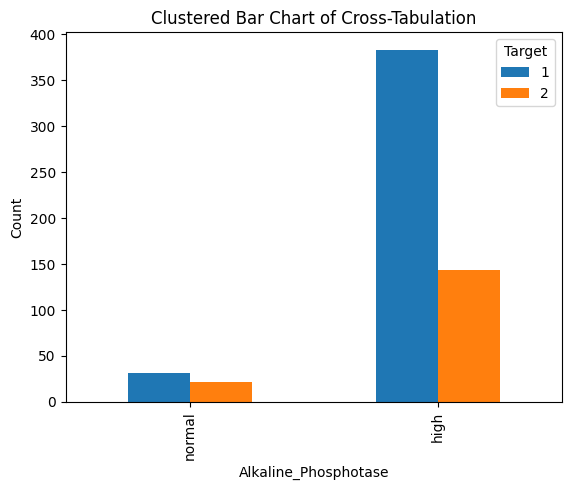

Cross-Tabulation:
Target                  1    2
Alkaline_Phosphotase          
normal                 31   22
high                  383  143
P-value: 0.04114083134687672


In [17]:
Xtab = pd.crosstab(df['Alkaline_Phosphotase'], df['Target'])

# Plot a clustered bar chart
Xtab.plot(kind='bar')
plt.title("Clustered Bar Chart of Cross-Tabulation")
plt.xlabel("Alkaline_Phosphotase")
plt.ylabel("Count")
plt.legend(title="Target")
plt.show()

# Perform the chi-square test
chi2, pval, dof, expected = chi2_contingency(Xtab)

# Output the results
print("Cross-Tabulation:")
print(Xtab)
print("P-value:", pval)

Elevated alkaline phosphotase levels are associated with liver disease.

### Aspartate_Aminotransferase vs Target

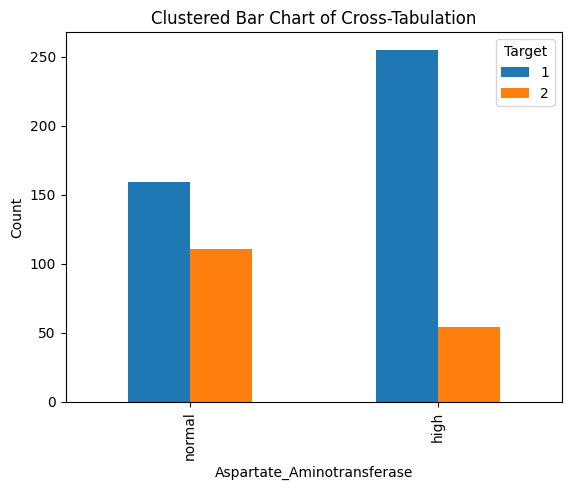

Cross-Tabulation:
Target                        1    2
Aspartate_Aminotransferase          
normal                      159  111
high                        255   54
P-value: 5.904809995525073e-10


In [18]:
Xtab = pd.crosstab(df['Aspartate_Aminotransferase'], df['Target'])

# Plot a clustered bar chart
Xtab.plot(kind='bar')
plt.title("Clustered Bar Chart of Cross-Tabulation")
plt.xlabel("Aspartate_Aminotransferase")
plt.ylabel("Count")
plt.legend(title="Target")
plt.show()

# Perform the chi-square test
chi2, pval, dof, expected = chi2_contingency(Xtab)

# Output the results
print("Cross-Tabulation:")
print(Xtab)
print("P-value:", pval)

Elevated AST levels are strongly associated with liver disease.

### Alamine_Aminotransferase vs Target

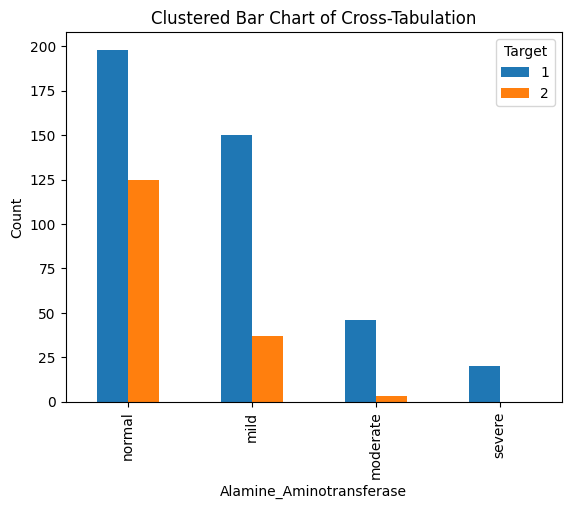

Cross-Tabulation:
Target                      1    2
Alamine_Aminotransferase          
normal                    198  125
mild                      150   37
moderate                   46    3
severe                     20    0
P-value: 1.951980496733952e-09


In [19]:
Xtab = pd.crosstab(df['Alamine_Aminotransferase'], df['Target'])

# Plot a clustered bar chart
Xtab.plot(kind='bar')
plt.title("Clustered Bar Chart of Cross-Tabulation")
plt.xlabel("Alamine_Aminotransferase")
plt.ylabel("Count")
plt.legend(title="Target")
plt.show()

# Perform the chi-square test
chi2, pval, dof, expected = chi2_contingency(Xtab)

# Output the results
print("Cross-Tabulation:")
print(Xtab)
print("P-value:", pval)

Increased ALT levels are associated with liver disease.

### Total_Proteins vs Target

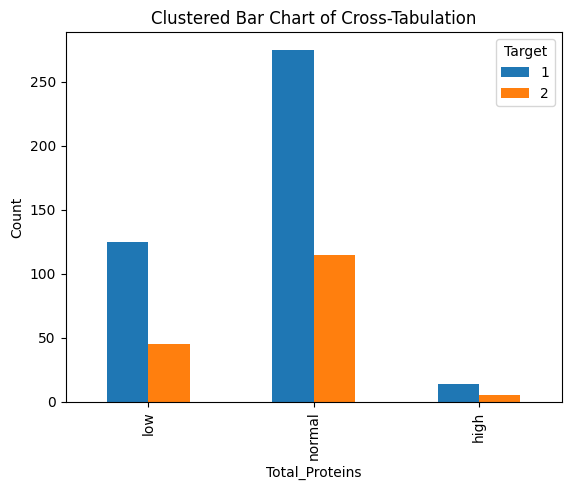

Cross-Tabulation:
Target            1    2
Total_Proteins          
low             125   45
normal          275  115
high             14    5
P-value: 0.7502820292737026


In [20]:
Xtab = pd.crosstab(df['Total_Proteins'], df['Target'])

# Plot a clustered bar chart
Xtab.plot(kind='bar')
plt.title("Clustered Bar Chart of Cross-Tabulation")
plt.xlabel("Total_Proteins")
plt.ylabel("Count")
plt.legend(title="Target")
plt.show()

# Perform the chi-square test
chi2, pval, dof, expected = chi2_contingency(Xtab)

# Output the results
print("Cross-Tabulation:")
print(Xtab)
print("P-value:", pval)

Total protein levels show moderate association, with considerable overlap between diseased and non-diseased groups.

### Albumin_Globulin Ratio vs Target

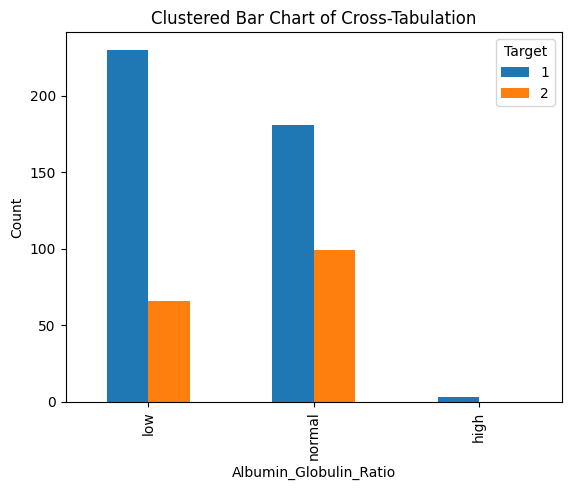

Cross-Tabulation:
Target                    1   2
Albumin_Globulin_Ratio         
low                     230  66
normal                  181  99
high                      3   0
P-value: 0.0013294165060835994


In [21]:
Xtab = pd.crosstab(df['Albumin_Globulin_Ratio'], df['Target'])

# Plot a clustered bar chart
Xtab.plot(kind='bar')
plt.title("Clustered Bar Chart of Cross-Tabulation")
plt.xlabel("Albumin_Globulin_Ratio")
plt.ylabel("Count")
plt.legend(title="Target")
plt.show()

# Perform the chi-square test
chi2, pval, dof, expected = chi2_contingency(Xtab)

# Output the results
print("Cross-Tabulation:")
print(Xtab)
print("P-value:", pval)

Lower A/G ratio is associated with liver disease.

### The features that are significantly associated with the likelihood of having liver disease are:

- High total bilirubin
- High direct bilirubin
- Elevated alkaline phosphotase (ALP)
- Elevated aspartate aminotransferase (AST)
- Elevated alamine aminotransferase (ALT)
- Low albumin levels
- Low albumin/globulin ratio

## Features Transformation
- Hot-encoding of all categorical variables will represent feature data, X
- `Target` variable will represent target data, y

In [22]:
columns = df[['Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Aspartate_Aminotransferase', 
              'Alamine_Aminotransferase', 'Albumin', 'Albumin_Globulin_Ratio', 'Target']]

# Perform one-hot encoding for the other columns
df = pd.get_dummies(columns, drop_first=True)

df.head()

,Target,Total_Bilirubin_high,Direct_Bilirubin_high,Alkaline_Phosphotase_normal,Alkaline_Phosphotase_high,Aspartate_Aminotransferase_normal,Aspartate_Aminotransferase_high,Alamine_Aminotransferase_mild,Alamine_Aminotransferase_moderate,Alamine_Aminotransferase_severe,Albumin_normal,Albumin_high,Albumin_Globulin_Ratio_normal,Albumin_Globulin_Ratio_high
0,1,False,False,False,True,True,False,False,False,False,False,False,False,False
1,1,True,True,False,True,False,True,True,False,False,False,False,False,False
2,1,True,True,False,True,False,True,True,False,False,False,False,False,False
3,1,False,True,False,True,True,False,False,False,False,True,False,True,False
4,1,True,True,False,True,False,True,False,False,False,False,False,False,False


In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 579 entries, 0 to 582
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Target                             579 non-null    int64
 1   Total_Bilirubin_high               579 non-null    bool 
 2   Direct_Bilirubin_high              579 non-null    bool 
 3   Alkaline_Phosphotase_normal        579 non-null    bool 
 4   Alkaline_Phosphotase_high          579 non-null    bool 
 5   Aspartate_Aminotransferase_normal  579 non-null    bool 
 6   Aspartate_Aminotransferase_high    579 non-null    bool 
 7   Alamine_Aminotransferase_mild      579 non-null    bool 
 8   Alamine_Aminotransferase_moderate  579 non-null    bool 
 9   Alamine_Aminotransferase_severe    579 non-null    bool 
 10  Albumin_normal                     579 non-null    bool 
 11  Albumin_high                       579 non-null    bool 
 12  Albumin_Globulin_Ratio_normal      579

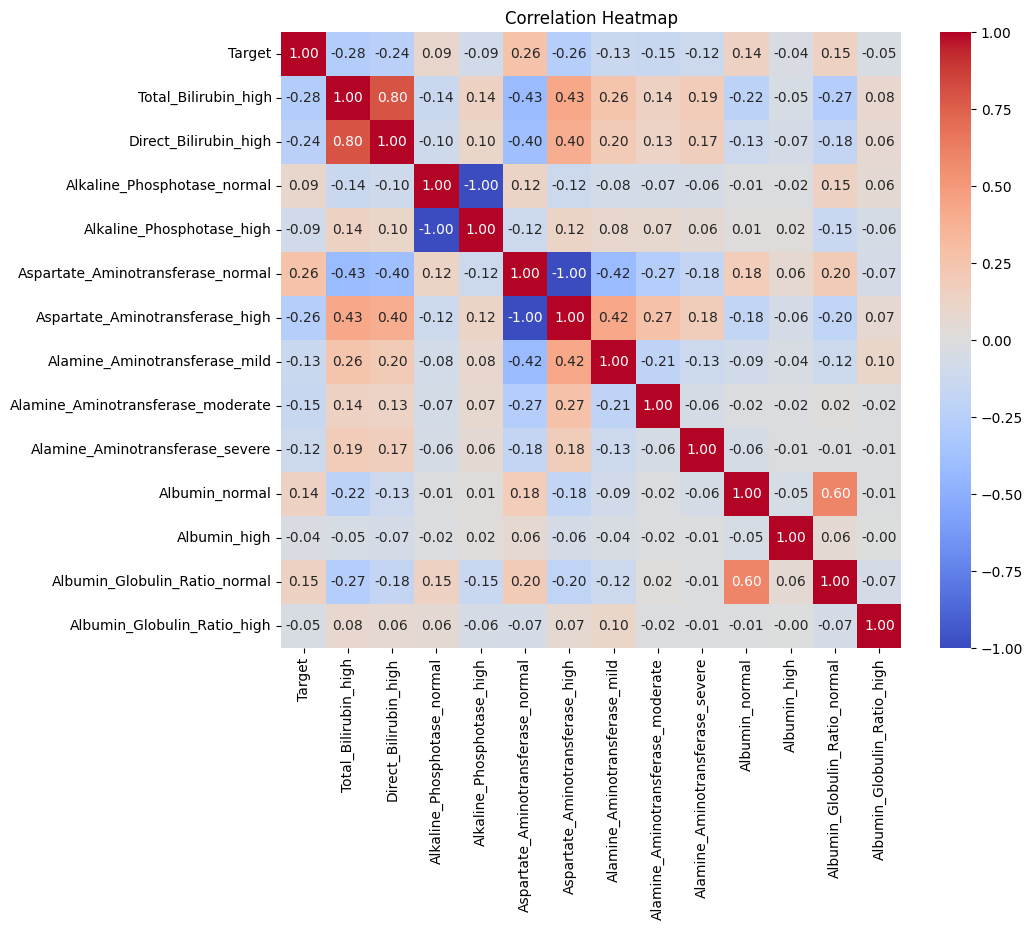

In [24]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))  # Adjust the figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Display the heatmap
plt.title("Correlation Heatmap")
plt.show()

# Predictive Models

## Data splitting

In [26]:
# Define X (features) and y (target)
X = df[['Total_Bilirubin_high', 
        'Direct_Bilirubin_high', 
        'Alkaline_Phosphotase_high',
        'Aspartate_Aminotransferase_high',
        'Alamine_Aminotransferase_mild',
        'Alamine_Aminotransferase_moderate',
        'Alamine_Aminotransferase_severe',
        'Albumin_normal',
        'Albumin_Globulin_Ratio_normal']]

y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Logistic Regression

In [27]:
# Create a Logistic Regression classifier
lr = LogisticRegression()

# Train the classifier on the training data
lr.fit(X_train, y_train)

# Make predictions on the test data
y_pred = lr.predict(X_test)

# Evaluate the classifier's performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print the evaluation results
print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.62
Confusion Matrix:
[[71  2]
 [42  1]]
Classification Report:
              precision    recall  f1-score   support

           1       0.63      0.97      0.76        73
           2       0.33      0.02      0.04        43

    accuracy                           0.62       116
   macro avg       0.48      0.50      0.40       116
weighted avg       0.52      0.62      0.50       116



## Hyperparameter Tuning

In [30]:
# Initialize model (handle class imbalance + avoid convergence issues)
lr = LogisticRegression(class_weight='balanced', max_iter=1000, solver='saga')

# Hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],   
    'l1_ratio': [0, 0.5, 1]   
}

# Grid search
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted'   
)

# Fit the grid search
grid_search.fit(X, y)

# Best results
print("Best Hyperparameters: ", grid_search.best_params_)
print("Best Cross-Validation Score: {:.2f}".format(grid_search.best_score_))

# Best model
best_logistic_regression = grid_search.best_estimator_

# Train on training set
best_logistic_regression.fit(X_train, y_train)

# Predictions
y_pred = best_logistic_regression.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, zero_division=0)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", confusion)
print("Classification Report:\n", classification_rep)

Best Hyperparameters:  {'C': 0.1, 'l1_ratio': 0.5}
Best Cross-Validation Score: 0.66
Accuracy: 0.6982758620689655
Confusion Matrix:
 [[48 25]
 [10 33]]
Classification Report:
               precision    recall  f1-score   support

           1       0.83      0.66      0.73        73
           2       0.57      0.77      0.65        43

    accuracy                           0.70       116
   macro avg       0.70      0.71      0.69       116
weighted avg       0.73      0.70      0.70       116

